# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql (a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.
- Note: the initial lab is opened as read only. To save work completed utilize the `save notebook as` option and give the lab a new name.

In [1]:
import requests

# start a spark session and create a spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("nyc_taxi") \
    .getOrCreate()

sc = spark.sparkContext

In [2]:
# set dl url for January 2019 trip data
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

# get the data
response = requests.get(download_url)

# check that response was good and save the data
jan_2019_trip_data = "yellow_tripdata_2019-01.parquet"
if response.status_code == 200:
    # Changed 'response' to 'data' here
    with open(jan_2019_trip_data, "wb") as f:
        f.write(response.content)


In [3]:
# create the dataframe
df_trips = spark.read.parquet(jan_2019_trip_data)

# A brief note on handling data sources in spark

The command above works well for loading data from parquet files because parquet is a self descibing file format, meaning that the metadata needed to build the dataframe is included directly in the format. However, when working with other formats such as csv or json, a schema must be provided or infered. In production code the schema should always be explicitly provided but during the data exploration phase it is acceptable to infer the schema, and when infering the schema it often best to use `.option("samplingRatio", <small-portion-of-data>)` to avoid using the entire dataset for schema inference.

```python
df_trips = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .option("samplingRatio", 0.01) \
    .load("large_dataset.csv")
```

In [4]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

In [5]:
from pyspark.sql.functions import monotonically_increasing_id

df_trips = df_trips.withColumn("trip_id", monotonically_increasing_id())
df_trips.select("trip_id", "passenger_count", "trip_distance").show(5)

+-----------+---------------+-------------+
|    trip_id|passenger_count|trip_distance|
+-----------+---------------+-------------+
|42949672960|            1.0|          1.5|
|42949672961|            1.0|          2.6|
|42949672962|            3.0|          0.0|
|42949672963|            5.0|          0.0|
|42949672964|            5.0|          0.0|
+-----------+---------------+-------------+
only showing top 5 rows


In [8]:
df_trips.groupBy("pickup_date").count().orderBy(col("count").asc()).show(1)    # jour le - chargé

+-----------+-----+
|pickup_date|count|
+-----------+-----+
| 2019-05-20|    1|
+-----------+-----+
only showing top 1 row


In [9]:
from pyspark.sql.functions import hour

df_trips = df_trips.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df_trips.groupBy("pickup_hour").count().orderBy(col("count").desc()).show(1)

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         18|515390|
+-----------+------+
only showing top 1 row


In [10]:
df_trips.groupBy("pickup_hour").count().orderBy(col("count").asc()).show(1)

+-----------+-----+
|pickup_hour|count|
+-----------+-----+
|          4|61424|
+-----------+-----+
only showing top 1 row


In [11]:
from pyspark.sql.functions import date_format

df_trips = df_trips.withColumn("pickup_dow", date_format("tpep_pickup_datetime", "EEEE"))
df_trips.groupBy("pickup_dow").count().orderBy(col("count").desc()).show()

+----------+-------+
|pickup_dow|  count|
+----------+-------+
|  Thursday|1357043|
| Wednesday|1265264|
|   Tuesday|1209084|
|    Friday|1087215|
|  Saturday|1009985|
|    Monday| 908121|
|    Sunday| 859905|
+----------+-------+



In [12]:
from pyspark.sql.functions import corr

df_trips.select(
    corr("trip_distance", "tip_amount").alias("corr_distance_tip"),
    corr("passenger_count", "tip_amount").alias("corr_passenger_tip")
).show()

+------------------+--------------------+
| corr_distance_tip|  corr_passenger_tip|
+------------------+--------------------+
|0.5269200663652668|0.001084223312167...|
+------------------+--------------------+



In [13]:
df_trips.orderBy(col("extra").desc()).select("trip_id", "extra", "trip_distance", "fare_amount").show(1)

+-----------+------+-------------+-----------+
|    trip_id| extra|trip_distance|fare_amount|
+-----------+------+-------------+-----------+
|42954996443|535.38|          0.0|  355676.98|
+-----------+------+-------------+-----------+
only showing top 1 row


### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough 
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

In [14]:
zone_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
response = requests.get(zone_url)
zone_lookup_file = "taxi_zone_lookup.csv"
if response.status_code == 200:
    with open(zone_lookup_file, "wb") as f:
        f.write(response.content)

df_zones = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(zone_lookup_file)

df_zones.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


In [15]:
df_trips_boroughs = df_trips \
    .join(
        df_zones.select("LocationID", "Borough").withColumnRenamed("LocationID", "PULocationID").withColumnRenamed("Borough", "PU_Borough"),
        on="PULocationID", how="left"
    ) \
    .join(
        df_zones.select("LocationID", "Borough").withColumnRenamed("LocationID", "DOLocationID").withColumnRenamed("Borough", "DO_Borough"),
        on="DOLocationID", how="left"
    )

df_trips_boroughs.select("trip_id", "PULocationID", "PU_Borough", "DOLocationID", "DO_Borough").show(5)

+-----------+------------+----------+------------+----------+
|    trip_id|PULocationID|PU_Borough|DOLocationID|DO_Borough|
+-----------+------------+----------+------------+----------+
|42949672960|         151| Manhattan|         239| Manhattan|
|42949672961|         239| Manhattan|         246| Manhattan|
|42949672962|         236| Manhattan|         236| Manhattan|
|42949672963|         193|    Queens|         193|    Queens|
|42949672964|         193|    Queens|         193|    Queens|
+-----------+------------+----------+------------+----------+
only showing top 5 rows


In [16]:
df_trips_boroughs.groupBy("PU_Borough").count().orderBy(col("count").desc()).show()

+-------------+-------+
|   PU_Borough|  count|
+-------------+-------+
|    Manhattan|6950965|
|       Queens| 471173|
|      Unknown| 159815|
|     Brooklyn|  91905|
|        Bronx|  18062|
|          N/A|   3890|
|          EWR|    446|
|Staten Island|    361|
+-------------+-------+



In [17]:
df_trips_boroughs.groupBy("DO_Borough").count().orderBy(col("count").desc()).show()

+-------------+-------+
|   DO_Borough|  count|
+-------------+-------+
|    Manhattan|6817355|
|       Queens| 340972|
|     Brooklyn| 301105|
|      Unknown| 149097|
|        Bronx|  58085|
|          N/A|  16904|
|          EWR|  10914|
|Staten Island|   2185|
+-------------+-------+



In [18]:
df_trips_boroughs.groupBy("PU_Borough", "pickup_hour").count().orderBy("PU_Borough", col("count").desc()).show(50)

+----------+-----------+-----+
|PU_Borough|pickup_hour|count|
+----------+-----------+-----+
|     Bronx|          7| 1803|
|     Bronx|          8| 1445|
|     Bronx|          6| 1301|
|     Bronx|          9| 1158|
|     Bronx|         10| 1079|
|     Bronx|         14| 1014|
|     Bronx|         12|  956|
|     Bronx|         13|  918|
|     Bronx|         15|  897|
|     Bronx|         11|  885|
|     Bronx|         17|  812|
|     Bronx|         16|  756|
|     Bronx|         18|  741|
|     Bronx|          5|  736|
|     Bronx|         19|  519|
|     Bronx|         20|  440|
|     Bronx|         23|  410|
|     Bronx|         21|  408|
|     Bronx|          4|  403|
|     Bronx|         22|  353|
|     Bronx|          0|  324|
|     Bronx|          1|  254|
|     Bronx|          3|  225|
|     Bronx|          2|  225|
|  Brooklyn|          8| 6935|
|  Brooklyn|          7| 6318|
|  Brooklyn|          9| 4691|
|  Brooklyn|          6| 4456|
|  Brooklyn|         23| 4342|
|  Brook

In [19]:
df_trips_boroughs.groupBy("PU_Borough", "pickup_dow").count().orderBy("PU_Borough", col("count").desc()).show(50)

+-------------+----------+-------+
|   PU_Borough|pickup_dow|  count|
+-------------+----------+-------+
|        Bronx|  Thursday|   3121|
|        Bronx|   Tuesday|   3059|
|        Bronx| Wednesday|   2999|
|        Bronx|    Friday|   2666|
|        Bronx|    Monday|   2177|
|        Bronx|    Sunday|   2112|
|        Bronx|  Saturday|   1928|
|     Brooklyn|   Tuesday|  15779|
|     Brooklyn|  Thursday|  15714|
|     Brooklyn| Wednesday|  15101|
|     Brooklyn|    Friday|  13092|
|     Brooklyn|  Saturday|  11604|
|     Brooklyn|    Sunday|  11099|
|     Brooklyn|    Monday|   9516|
|          EWR| Wednesday|     83|
|          EWR|   Tuesday|     77|
|          EWR|    Friday|     74|
|          EWR|    Sunday|     68|
|          EWR|  Thursday|     58|
|          EWR|  Saturday|     55|
|          EWR|    Monday|     31|
|    Manhattan|  Thursday|1229554|
|    Manhattan| Wednesday|1144782|
|    Manhattan|   Tuesday|1086202|
|    Manhattan|    Friday| 984950|
|    Manhattan|  Sat

In [20]:
from pyspark.sql.functions import avg

df_trips_boroughs.groupBy("PU_Borough").agg(avg("trip_distance").alias("avg_distance")).orderBy(col("avg_distance").desc()).show()

+-------------+------------------+
|   PU_Borough|      avg_distance|
+-------------+------------------+
|Staten Island|12.503601108033246|
|       Queens|11.283218499361993|
|        Bronx| 7.233194552098303|
|     Brooklyn| 4.787677275447492|
|          N/A| 3.193850899742941|
|          EWR| 2.641098654708519|
|      Unknown| 2.415464130400774|
|    Manhattan|2.2286693358402596|
+-------------+------------------+



In [21]:
df_trips_boroughs.groupBy("PU_Borough").agg(avg("fare_amount").alias("avg_fare")).orderBy(col("avg_fare").desc()).show()

+-------------+------------------+
|   PU_Borough|          avg_fare|
+-------------+------------------+
|          EWR| 76.24024663677126|
|          N/A|  59.5731593830335|
|Staten Island|45.289861495844896|
|       Queens| 35.14462651722029|
|        Bronx| 26.26890543682963|
|     Brooklyn|18.649132800172286|
|      Unknown|14.944423051653523|
|    Manhattan|10.792468572351568|
+-------------+------------------+



In [22]:
df_trips_boroughs.orderBy(col("fare_amount").desc()).select("trip_id", "fare_amount", "PU_Borough").show(1)
df_trips_boroughs.orderBy(col("fare_amount").asc()).select("trip_id", "fare_amount", "PU_Borough").show(1)

+-----------+-----------+----------+
|    trip_id|fare_amount|PU_Borough|
+-----------+-----------+----------+
|42952172615|  623259.86| Manhattan|
+-----------+-----------+----------+
only showing top 1 row
+-----------+-----------+----------+
|    trip_id|fare_amount|PU_Borough|
+-----------+-----------+----------+
|42954563609|     -362.0|    Queens|
+-----------+-----------+----------+
only showing top 1 row


In [23]:
def load_trip_data(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
    return spark.read.parquet(filename)

download_url_2025 = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet'
df_trips_2025 = load_trip_data(download_url_2025, "yellow_tripdata_2025-01.parquet")

df_trips_2025.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|              1|          1.6|         1|                 N|         229|    

In [24]:
from pyspark.sql.functions import avg

print("Janvier 2019 :")
df_trips.select(avg("passenger_count"), avg("trip_distance"), avg("fare_amount")).show()

print("Janvier 2025 :")
df_trips_2025.select(avg("passenger_count"), avg("trip_distance"), avg("fare_amount")).show()

Janvier 2019 :
+--------------------+------------------+-----------------+
|avg(passenger_count)|avg(trip_distance)| avg(fare_amount)|
+--------------------+------------------+-----------------+
|  1.5670317144945614|2.8301461681153532|12.52967677747685|
+--------------------+------------------+-----------------+

Janvier 2025 :
+--------------------+------------------+-----------------+
|avg(passenger_count)|avg(trip_distance)| avg(fare_amount)|
+--------------------+------------------+-----------------+
|  1.2978589658806226| 5.855126178843539|17.08180276045484|
+--------------------+------------------+-----------------+



### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

In [26]:
df_trips.createOrReplaceTempView("trips")
df_zones.createOrReplaceTempView("zones")

In [27]:
spark.sql("""
    SELECT avg(passenger_count) AS avg_passenger_count
    FROM trips
""").show()

+-------------------+
|avg_passenger_count|
+-------------------+
| 1.5670317144945614|
+-------------------+



In [28]:
spark.sql("""
    SELECT trip_id, fare_amount
    FROM trips
    ORDER BY fare_amount DESC
    LIMIT 1
""").show()

+-----------+-----------+
|    trip_id|fare_amount|
+-----------+-----------+
|42952172615|  623259.86|
+-----------+-----------+



In [29]:
spark.sql("""
    SELECT z.Borough AS PU_Borough, count(*) AS trip_count
    FROM trips t
    JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY trip_count DESC
""").show()

+-------------+----------+
|   PU_Borough|trip_count|
+-------------+----------+
|    Manhattan|   6950965|
|       Queens|    471173|
|      Unknown|    159815|
|     Brooklyn|     91905|
|        Bronx|     18062|
|          N/A|      3890|
|          EWR|       446|
|Staten Island|       361|
+-------------+----------+



# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.
- Explore a dataset/datasets of your choosing

In [31]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 3.8 MB/s  0:00:02 eta 0:00:01


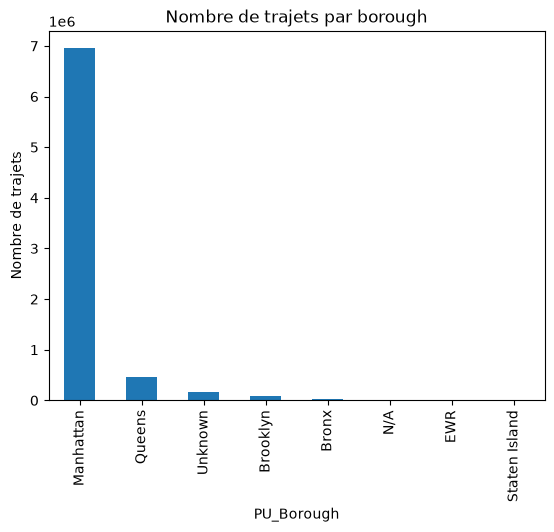

In [40]:
import matplotlib.pyplot as plt

pdf1 = df_trips_boroughs.groupBy("PU_Borough").count().orderBy(col("count").desc()).toPandas()
pdf1.plot(kind="bar", x="PU_Borough", y="count", legend=False)
plt.title("Nombre de trajets par borough")
plt.ylabel("Nombre de trajets")
plt.show()

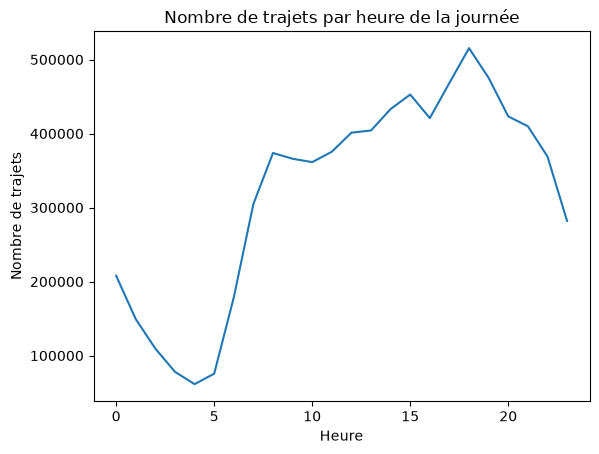

In [41]:
pdf2 = df_trips.groupBy("pickup_hour").count().orderBy("pickup_hour").toPandas()
pdf2.plot(kind="line", x="pickup_hour", y="count", legend=False)
plt.title("Nombre de trajets par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Nombre de trajets")
plt.show()

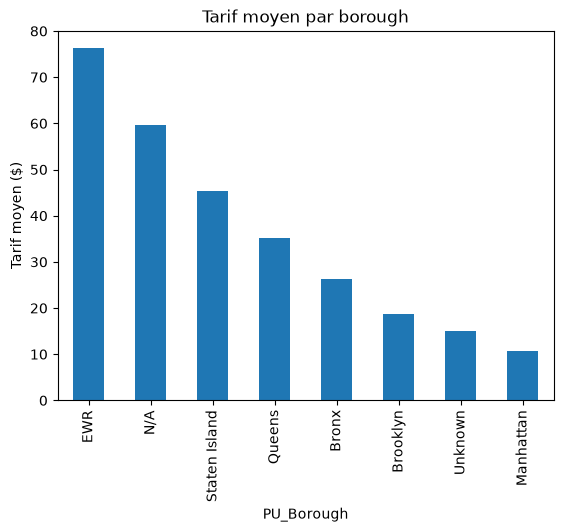

In [42]:
pdf3 = df_trips_boroughs.groupBy("PU_Borough").agg(avg("fare_amount").alias("avg_fare")).orderBy(col("avg_fare").desc()).toPandas()
pdf3.plot(kind="bar", x="PU_Borough", y="avg_fare", legend=False)
plt.title("Tarif moyen par borough")
plt.ylabel("Tarif moyen ($)")
plt.show()